In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', ".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from database import FY3DImageArea, FY3DImage
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from utils.some_utils import change_contrast
import seaborn as sns
import pandas as pd
import numpy as np

np.set_printoptions(suppress=True)

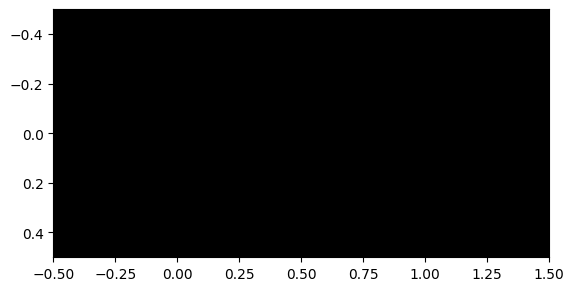

In [2]:
# %matplotlib widget
plt.imshow([(0, 0)], cmap="gray")

SEA 453.03
CLOSE ICE 3717.73
ICE 4095.0
BOTTOM ICE 2965.07


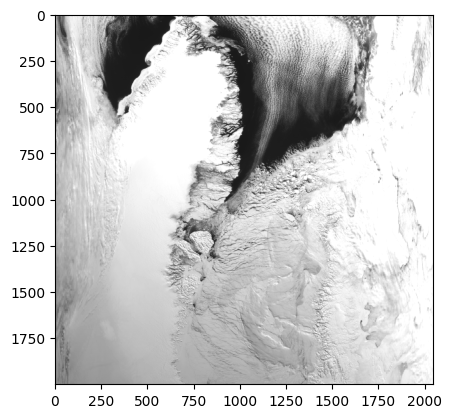

In [3]:
# Оригинальное изображение
img = FY3DImage.get(id=119)
CHANNEL = 12
ch_img = img.get_vis_channel(CHANNEL)
plt.imshow(ch_img, cmap="gray")

points = [
    (350, 300, "SEA"),
    (475, 300, "CLOSE ICE"),
    (650, 360, "ICE"),
    (300, 1700, "BOTTOM ICE"),
]

for x, y, label in points:
    print(label, ch_img[y: y+10, x: x+10].mean())

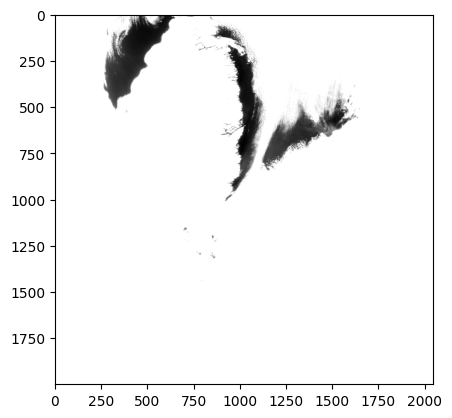

In [4]:
# Изменение контраста
MIN = 400
MAX = 700
contrasted_img = change_contrast(ch_img, MIN, MAX)
plt.imshow(contrasted_img, cmap="gray")

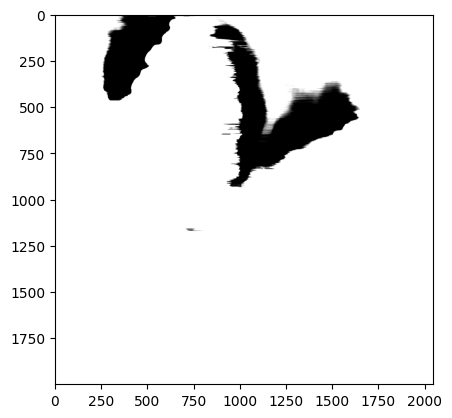

In [5]:
# Применение медианы
kernel = (1, 100)
median_img = median_filter(ch_img, size=kernel)
contrasted_median = change_contrast(median_img, 1000, 1300)
plt.imshow(contrasted_median, cmap="gray")

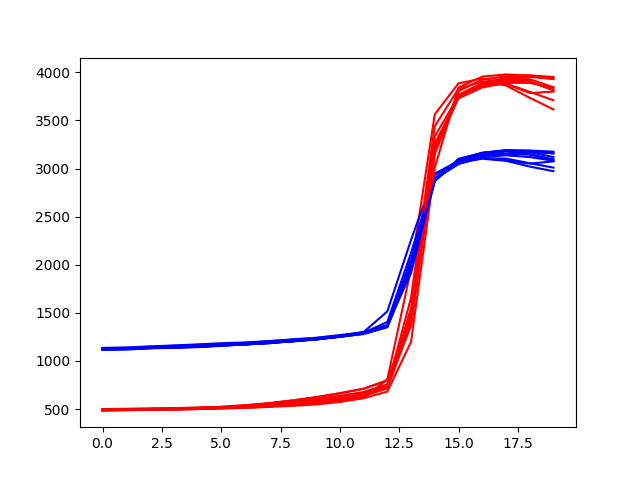

In [41]:
%matplotlib widget
y = 410
x = 400
w = 20
h = 10

ara12 = FY3DImage.get(id=119).get_vis_channel(12)[y: y+h, x: x+w]
ara8 = FY3DImage.get(id=119).get_vis_channel(8)[y: y+h, x: x+w]

plt.close()
for sensor in range(10):
    plt.plot(list(range(w)), ara12[sensor], color="red")
    plt.plot(list(range(w)), ara8[sensor], color="blue")
plt.show()

In [35]:
plt.imshow(ara12, cmap="gray")